In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

In [2]:
import pandas as pd

file_path = r"D:\clv\online_retail_II.xlsx"

# Load both sheets
df_2009 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

# Combine them
df = pd.concat([df_2009, df_2010], ignore_index=True)

print("Dataset Loaded Successfully")
print(f"Shape: {df.shape}")

Dataset Loaded Successfully
Shape: (1067371, 8)


In [3]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

DATASET SHAPE
Rows    : 1,067,371
Columns : 8


In [4]:
display(df.head())

display(df.tail())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [5]:
print("Columns:\n")

for col in df.columns:
    print(col)

Columns:

Invoice
StockCode
Description
Quantity
InvoiceDate
Price
Customer ID
Country


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [7]:
dtype_summary = (
    df.dtypes
      .reset_index()
      .rename(columns={
          "index":"Column",
          0:"Data Type"
      })
)

display(dtype_summary)

,Column,Data Type
0,Invoice,object
1,StockCode,object
2,Description,object
3,Quantity,int64
4,InvoiceDate,datetime64[us]
5,Price,float64
6,Customer ID,float64
7,Country,str


In [8]:
display(df.describe())

display(df.describe(include="object"))

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


C:\Users\Urvi Patel\AppData\Local\Temp\ipykernel_6744\1626320548.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,Invoice,StockCode,Description,Country
count,1067371,1067371,1062989,1067371
unique,53628,5305,5698,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1350,5829,5918,981330


In [9]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

display(unique_values)

,Unique Values
Invoice,53628
StockCode,5305
Description,5698
Quantity,1057
InvoiceDate,47635
Price,2807
Customer ID,5942
Country,43


In [10]:
for column in df.columns:

    print("=" * 60)
    print(column)
    print("=" * 60)

    print(df[column].dropna().unique()[:10])

    print()

Invoice
[489434 489435 489436 489437 489438 489439 489440 489441 489442 489443]

StockCode
[85048 '79323P' '79323W' 22041 21232 22064 21871 21523 22350 22349]

Description
['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' 'RECORD FRAME 7" SINGLE SIZE '
 'STRAWBERRY CERAMIC TRINKET BOX' 'PINK DOUGHNUT TRINKET POT '
 'SAVE THE PLANET MUG' 'FANCY FONT HOME SWEET HOME DOORMAT' 'CAT BOWL '
 'DOG BOWL , CHASING BALL DESIGN']

Quantity
[12 48 24 10 18  3 16  4  2  6]

InvoiceDate
<DatetimeArray>
['2009-12-01 07:45:00', '2009-12-01 07:46:00', '2009-12-01 09:06:00',
 '2009-12-01 09:08:00', '2009-12-01 09:24:00', '2009-12-01 09:28:00',
 '2009-12-01 09:43:00', '2009-12-01 09:44:00', '2009-12-01 09:46:00',
 '2009-12-01 09:50:00']
Length: 10, dtype: datetime64[us]

Price
[6.95 6.75 2.1  1.25 1.65 5.95 2.55 3.75 5.45 1.69]

Customer ID
[13085. 13078. 15362. 18102. 12682. 18087. 13635. 14110. 12636. 17519.]

Country
<ArrowStringArray>
['United Kingdom',         'Fran

In [11]:
print("Earliest Transaction : ", df["InvoiceDate"].min())

print("Latest Transaction   : ", df["InvoiceDate"].max())

Earliest Transaction :  2009-12-01 07:45:00
Latest Transaction   :  2011-12-09 12:50:00


In [12]:
print("Unique Customers")

print(df["Customer ID"].nunique())

Unique Customers
5942


In [13]:
print("Unique Products")

print(df["StockCode"].nunique())

Unique Products
5305


In [14]:
print("Countries")

display(df["Country"].value_counts())

Countries


Country
United Kingdom          981330
EIRE                     17866
Germany                  17624
France                   14330
Netherlands               5140
Spain                     3811
Switzerland               3189
Belgium                   3123
Portugal                  2620
Australia                 1913
Channel Islands           1664
Italy                     1534
Norway                    1455
Sweden                    1364
Cyprus                    1176
Finland                   1049
Austria                    938
Denmark                    817
Unspecified                756
Greece                     663
Japan                      582
USA                        535
Poland                     535
United Arab Emirates       500
Israel                     371
Hong Kong                  364
Singapore                  346
Malta                      299
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        169


In [15]:
summary = pd.DataFrame({

    "Metric":[
        "Rows",
        "Columns",
        "Customers",
        "Products",
        "Countries"
    ],

    "Value":[
        df.shape[0],
        df.shape[1],
        df["Customer ID"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique()
    ]

})

display(summary)

,Metric,Value
0,Rows,1067371
1,Columns,8
2,Customers,5942
3,Products,5305
4,Countries,43


In [16]:
missing = pd.DataFrame({

    "Missing Values":df.isna().sum(),

    "Percentage":(
        df.isna().mean()*100
    ).round(2)

})

display(
    missing.sort_values(
        "Percentage",
        ascending=False
    )
)

,Missing Values,Percentage
Customer ID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [18]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates:,}")

Duplicate Rows : 34,335


In [19]:
customer_duplicates = (
    df["Customer ID"]
    .duplicated()
    .sum()
)

print(customer_duplicates)

1061428


In [20]:
negative_qty = df[df["Quantity"] < 0]

print("Negative Quantity Records")

print(negative_qty.shape[0])

display(negative_qty.head())

Negative Quantity Records
22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [21]:
zero_price = df[df["Price"] == 0]

print(zero_price.shape[0])

display(zero_price.head())

6202


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


In [22]:
negative_price = df[df["Price"] < 0]

print(negative_price.shape[0])

5


In [23]:
cancelled = df[
    df["Invoice"].astype(str).str.startswith("C")
]

print(cancelled.shape[0])

display(cancelled.head())

19494


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [24]:
display(

    df[
        df["Customer ID"].isna()
    ]

)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1066997,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
1066998,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
1066999,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
1067000,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


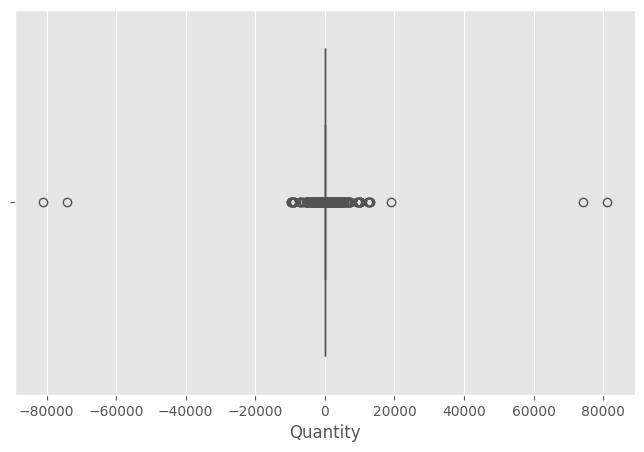

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Quantity"]
)

plt.show()

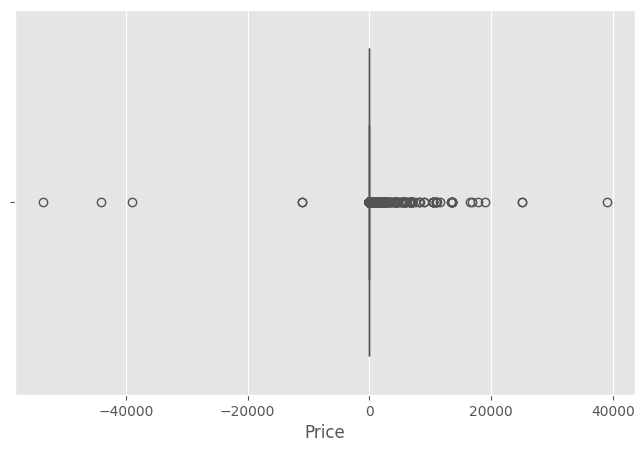

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Price"]
)

plt.show()

In [27]:
invoice_summary = (

    df.groupby("Invoice")

    .agg({

        "Quantity":"sum",

        "Price":"mean"

    })

)

display(invoice_summary.head())

,Quantity,Price
Invoice,,
489434,166,4.081250
489435,60,2.625000
489436,193,3.730526
489437,145,3.628261
489438,826,2.591176


In [28]:
purchase_frequency = (

    df.groupby("Customer ID")

    .size()

)

display(

    purchase_frequency.describe()

)

count     5942.000000
mean       138.735106
std        359.689585
min          1.000000
25%         21.000000
50%         53.000000
75%        144.000000
max      13097.000000
dtype: float64

In [29]:
country = (

    df["Country"]

    .value_counts()

)

display(country)

Country
United Kingdom          981330
EIRE                     17866
Germany                  17624
France                   14330
Netherlands               5140
Spain                     3811
Switzerland               3189
Belgium                   3123
Portugal                  2620
Australia                 1913
Channel Islands           1664
Italy                     1534
Norway                    1455
Sweden                    1364
Cyprus                    1176
Finland                   1049
Austria                    938
Denmark                    817
Unspecified                756
Greece                     663
Japan                      582
USA                        535
Poland                     535
United Arab Emirates       500
Israel                     371
Hong Kong                  364
Singapore                  346
Malta                      299
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        169
